<a href="https://colab.research.google.com/github/l22140199-ops/Analisis-y-visualizacion-de-datos/blob/main/Toma_de_Decisiones_Basada_en_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
  Instalación de paqueterías

In [4]:
paquetes <- c(
  "tidyverse",
  "readxl",
  "lubridate",
  "janitor",
  "scales",
  "broom"
)

instalar <- paquetes[!paquetes %in% installed.packages()[, "Package"]]

if (length(instalar) > 0) {
  install.packages(instalar, dependencies = TRUE)
}

Instalación de librerias

In [5]:
library(tidyverse)
library(readxl)
library(lubridate)
library(janitor)
library(scales)
library(broom)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test



Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




Configuración del archivo y carpetas

In [7]:
archivo <- "/content/Base_Datos_Unidad5_DDDM.xlsx"

if (!file.exists(archivo)) {
  stop("No se encontró el archivo. Sube Base_Datos_Unidad5_DDDM.xlsx a la carpeta /content de Colab.")
}

dir.create("/content/resultados", showWarnings = FALSE)
dir.create("/content/resultados/graficas", showWarnings = FALSE, recursive = TRUE)

convertir_fecha <- function(x) {
  if (inherits(x, "Date")) return(x)
  if (inherits(x, "POSIXt")) return(as.Date(x))
  if (is.numeric(x)) return(as.Date(x, origin = "1899-12-30"))
  suppressWarnings(as.Date(x))
}

Importar hojas de excel

In [8]:
excel_sheets(archivo)

sucursales <- read_excel(archivo, sheet = "Sucursales") |> clean_names()
productos <- read_excel(archivo, sheet = "Productos") |> clean_names()
clientes <- read_excel(archivo, sheet = "Clientes") |> clean_names()
vendedores <- read_excel(archivo, sheet = "Vendedores") |> clean_names()
calendario <- read_excel(archivo, sheet = "Calendario") |> clean_names()
ventas <- read_excel(archivo, sheet = "Ventas") |> clean_names()
metas <- read_excel(archivo, sheet = "MetasMensuales") |> clean_names()
encuesta <- read_excel(archivo, sheet = "Encuesta") |> clean_names()
simulacion_param <- read_excel(archivo, sheet = "Simulacion_MC", range = "B5:G9") |> clean_names()

[1] "Inicio"         "Sucursales"     "Productos"      "Clientes"      
 [5] "Vendedores"     "Calendario"     "Ventas"         "MetasMensuales"
 [9] "Encuesta"       "Simulacion_MC"  "Diccionario"

Explorar estructuras de datos

In [9]:
glimpse(ventas)
summary(ventas)

glimpse(productos)
glimpse(sucursales)
glimpse(clientes)
glimpse(encuesta)

Rows: 1,200
Columns: 11
$ venta_id        <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,…
$ fecha           <dttm> 2025-01-01, 2025-01-01, 2025-01-02, 2025-01-03, 2025-…
$ sucursal_id     <dbl> 1, 2, 2, 1, 1, 5, 1, 1, 2, 5, 1, 5, 4, 4, 3, 1, 4, 1, …
$ vendedor_id     <dbl> 3, 4, 5, 3, 1, 10, 2, 1, 4, 10, 3, 10, 8, 9, 7, 3, 8, …
$ cliente_id      <dbl> 44, 44, 46, 28, 3, 30, 36, 13, 9, 27, 3, 30, 26, 36, 4…
$ producto_id     <dbl> 15, 3, 7, 16, 2, 20, 3, 9, 20, 16, 15, 14, 3, 20, 2, 1…
$ cantidad        <dbl> 1, 1, 1, 2, 4, 2, 2, 2, 2, 2, 2, 3, 3, 2, 2, 2, 2, 1, …
$ precio_unitario <dbl> 65, 38, 50, 45, 45, 88, 38, 40, 88, 45, 65, 38, 38, 88…
$ descuento_pct   <dbl> 0.00, 0.05, 0.05, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, …
$ importe_bruto   <dbl> 65, 38, 50, 90, 180, 176, 76, 80, 176, 90, 130, 114, 1…
$ importe_neto    <dbl> 65.0, 36.1, 47.5, 90.0, 180.0, 176.0, 76.0, 80.0, 176.…


    venta_id          fecha                      sucursal_id   
 Min.   :   1.0   Min.   :2025-01-01 00:00:00   Min.   :1.000  
 1st Qu.: 300.8   1st Qu.:2025-04-26 00:00:00   1st Qu.:1.000  
 Median : 600.5   Median :2025-07-29 00:00:00   Median :3.000  
 Mean   : 600.5   Mean   :2025-07-20 19:56:24   Mean   :2.729  
 3rd Qu.: 900.2   3rd Qu.:2025-10-20 06:00:00   3rd Qu.:4.000  
 Max.   :1200.0   Max.   :2025-12-31 00:00:00   Max.   :5.000  
  vendedor_id       cliente_id     producto_id       cantidad    
 Min.   : 1.000   Min.   : 1.00   Min.   : 1.00   Min.   :1.000  
 1st Qu.: 3.000   1st Qu.:14.00   1st Qu.: 5.00   1st Qu.:1.000  
 Median : 6.000   Median :29.00   Median :11.00   Median :1.000  
 Mean   : 5.781   Mean   :29.11   Mean   :10.55   Mean   :1.741  
 3rd Qu.: 8.000   3rd Qu.:43.00   3rd Qu.:15.00   3rd Qu.:2.000  
 Max.   :10.000   Max.   :60.00   Max.   :20.00   Max.   :5.000  
 precio_unitario  descuento_pct     importe_bruto    importe_neto   
 Min.   : 28.00   Min

Rows: 20
Columns: 7
$ producto_id     <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,…
$ sku             <chr> "CAF-001", "CAF-002", "CAF-003", "CAF-004", "CAF-005",…
$ nombre          <chr> "Espresso Sencillo", "Espresso Doble", "Americano", "C…
$ categoria       <chr> "Café", "Café", "Café", "Café", "Café", "Café", "Té", …
$ costo           <dbl> 15, 22, 16, 24, 26, 28, 20, 22, 14, 30, 32, 18, 12, 15…
$ precio          <dbl> 35, 45, 38, 55, 58, 62, 50, 52, 40, 70, 72, 45, 32, 38…
$ margen_unitario <dbl> 20, 23, 22, 31, 32, 34, 30, 30, 26, 40, 40, 27, 20, 23…
Rows: 5
Columns: 7
$ sucursal_id    <dbl> 1, 2, 3, 4, 5
$ codigo         <chr> "QRO-CTR", "SJR-001", "CEL-001", "LEO-001", "AGS-001"
$ nombre         <chr> "Querétaro Centro", "San Juan del Río", "Celaya Plaza V…
$ estado         <chr> "Querétaro", "Querétaro", "Guanajuato", "Guanajuato", "…
$ tamano         <chr> "Grande", "Mediana", "Mediana", "Grande", "Pequeña"
$ fecha_apertura <chr> "2018-03-15", "2019-08-01", "

Limpiar y transformar los datos

In [10]:
sucursales <- sucursales |>
  mutate(fecha_apertura = convertir_fecha(fecha_apertura)) |>
  rename(
    sucursal = nombre,
    estado_sucursal = estado,
    tamano_sucursal = tamano
  )

productos <- productos |>
  rename(
    producto = nombre,
    categoria_producto = categoria
  )

clientes <- clientes |>
  mutate(fecha_registro = convertir_fecha(fecha_registro)) |>
  rename(
    cliente = nombre,
    ciudad_cliente = ciudad,
    segmento_cliente = segmento
  )

vendedores <- vendedores |>
  mutate(fecha_ingreso = convertir_fecha(fecha_ingreso)) |>
  rename(
    vendedor = nombre,
    nivel_vendedor = nivel
  )

calendario <- calendario |>
  mutate(fecha = convertir_fecha(fecha))

ventas <- ventas |>
  mutate(
    fecha = convertir_fecha(fecha),
    cantidad = as.numeric(cantidad),
    precio_unitario = as.numeric(precio_unitario),
    descuento_pct = as.numeric(descuento_pct),
    importe_bruto = as.numeric(importe_bruto),
    importe_neto = as.numeric(importe_neto)
  ) |>
  filter(
    !is.na(venta_id),
    !is.na(fecha),
    !is.na(importe_neto),
    importe_neto >= 0
  )

metas <- metas |>
  filter(!is.na(meta_id))

encuesta <- encuesta |>
  mutate(fecha = convertir_fecha(fecha)) |>
  filter(!is.na(encuesta_id))

Crear modelo de datos unidos

In [11]:
ventas_modelo <- ventas |>
  left_join(productos, by = "producto_id") |>
  left_join(sucursales, by = "sucursal_id") |>
  left_join(vendedores, by = c("vendedor_id", "sucursal_id")) |>
  left_join(clientes, by = "cliente_id") |>
  left_join(calendario, by = "fecha") |>
  mutate(
    utilidad_bruta_estimada = ((precio_unitario * (1 - descuento_pct)) - costo) * cantidad,
    margen_pct = utilidad_bruta_estimada / importe_neto
  )

glimpse(ventas_modelo)
summary(ventas_modelo)

Rows: 1,200
Columns: 41
$ venta_id                <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14,…
$ fecha                   <date> 2025-01-01, 2025-01-01, 2025-01-02, 2025-01-0…
$ sucursal_id             <dbl> 1, 2, 2, 1, 1, 5, 1, 1, 2, 5, 1, 5, 4, 4, 3, 1…
$ vendedor_id             <dbl> 3, 4, 5, 3, 1, 10, 2, 1, 4, 10, 3, 10, 8, 9, 7…
$ cliente_id              <dbl> 44, 44, 46, 28, 3, 30, 36, 13, 9, 27, 3, 30, 2…
$ producto_id             <dbl> 15, 3, 7, 16, 2, 20, 3, 9, 20, 16, 15, 14, 3, …
$ cantidad                <dbl> 1, 1, 1, 2, 4, 2, 2, 2, 2, 2, 2, 3, 3, 2, 2, 2…
$ precio_unitario         <dbl> 65, 38, 50, 45, 45, 88, 38, 40, 88, 45, 65, 38…
$ descuento_pct           <dbl> 0.00, 0.05, 0.05, 0.00, 0.00, 0.00, 0.00, 0.00…
$ importe_bruto           <dbl> 65, 38, 50, 90, 180, 176, 76, 80, 176, 90, 130…
$ importe_neto            <dbl> 65.0, 36.1, 47.5, 90.0, 180.0, 176.0, 76.0, 80…
$ sku                     <chr> "REP-003", "CAF-003", "TE-001", "REP-004", "CA…
$ producto      

    venta_id          fecha             sucursal_id     vendedor_id    
 Min.   :   1.0   Min.   :2025-01-01   Min.   :1.000   Min.   : 1.000  
 1st Qu.: 300.8   1st Qu.:2025-04-26   1st Qu.:1.000   1st Qu.: 3.000  
 Median : 600.5   Median :2025-07-29   Median :3.000   Median : 6.000  
 Mean   : 600.5   Mean   :2025-07-20   Mean   :2.729   Mean   : 5.781  
 3rd Qu.: 900.2   3rd Qu.:2025-10-20   3rd Qu.:4.000   3rd Qu.: 8.000  
 Max.   :1200.0   Max.   :2025-12-31   Max.   :5.000   Max.   :10.000  
   cliente_id     producto_id       cantidad     precio_unitario 
 Min.   : 1.00   Min.   : 1.00   Min.   :1.000   Min.   : 28.00  
 1st Qu.:14.00   1st Qu.: 5.00   1st Qu.:1.000   1st Qu.: 40.00  
 Median :29.00   Median :11.00   Median :1.000   Median : 52.00  
 Mean   :29.11   Mean   :10.55   Mean   :1.741   Mean   : 58.39  
 3rd Qu.:43.00   3rd Qu.:15.00   3rd Qu.:2.000   3rd Qu.: 70.00  
 Max.   :60.00   Max.   :20.00   Max.   :5.000   Max.   :125.00  
 descuento_pct     importe_bruto  

KPI´S generales

In [12]:
kpi_general <- tibble(
  indicador = c(
    "Ventas netas",
    "Ventas brutas",
    "Descuento total",
    "Transacciones",
    "Unidades vendidas",
    "Ticket promedio",
    "Utilidad bruta estimada",
    "Margen bruto estimado"
  ),
  valor = c(
    sum(ventas_modelo$importe_neto, na.rm = TRUE),
    sum(ventas_modelo$importe_bruto, na.rm = TRUE),
    sum(ventas_modelo$importe_bruto - ventas_modelo$importe_neto, na.rm = TRUE),
    nrow(ventas_modelo),
    sum(ventas_modelo$cantidad, na.rm = TRUE),
    mean(ventas_modelo$importe_neto, na.rm = TRUE),
    sum(ventas_modelo$utilidad_bruta_estimada, na.rm = TRUE),
    sum(ventas_modelo$utilidad_bruta_estimada, na.rm = TRUE) / sum(ventas_modelo$importe_neto, na.rm = TRUE)
  )
)

print(kpi_general)

write_csv(kpi_general, "/content/resultados/01_kpi_general.csv")

# A tibble: 8 × 2
  indicador                    valor
  <chr>                        <dbl>
1 Ventas netas            119872.   
2 Ventas brutas           121709    
3 Descuento total           1837.   
4 Transacciones             1200    
5 Unidades vendidas         2089    
6 Ticket promedio             99.9  
7 Utilidad bruta estimada  68350.   
8 Margen bruto estimado        0.570


Análisis por mes, sucursal y categoría

In [13]:
ventas_mensuales <- ventas_modelo |>
  group_by(ano, mes, nombre_mes) |>
  summarise(
    ventas_netas = sum(importe_neto, na.rm = TRUE),
    transacciones = n(),
    unidades = sum(cantidad, na.rm = TRUE),
    ticket_promedio = mean(importe_neto, na.rm = TRUE),
    utilidad_bruta = sum(utilidad_bruta_estimada, na.rm = TRUE),
    .groups = "drop"
  ) |>
  arrange(ano, mes)

ventas_sucursal <- ventas_modelo |>
  group_by(sucursal, estado_sucursal, tamano_sucursal) |>
  summarise(
    ventas_netas = sum(importe_neto, na.rm = TRUE),
    transacciones = n(),
    unidades = sum(cantidad, na.rm = TRUE),
    ticket_promedio = mean(importe_neto, na.rm = TRUE),
    utilidad_bruta = sum(utilidad_bruta_estimada, na.rm = TRUE),
    .groups = "drop"
  ) |>
  arrange(desc(ventas_netas))

ventas_categoria <- ventas_modelo |>
  group_by(categoria_producto) |>
  summarise(
    ventas_netas = sum(importe_neto, na.rm = TRUE),
    unidades = sum(cantidad, na.rm = TRUE),
    utilidad_bruta = sum(utilidad_bruta_estimada, na.rm = TRUE),
    .groups = "drop"
  ) |>
  arrange(desc(ventas_netas))

write_csv(ventas_mensuales, "/content/resultados/02_ventas_mensuales.csv")
write_csv(ventas_sucursal, "/content/resultados/03_ventas_sucursal.csv")
write_csv(ventas_categoria, "/content/resultados/04_ventas_categoria.csv")

print(ventas_mensuales)
print(ventas_sucursal)
print(ventas_categoria)

# A tibble: 12 × 8
     ano   mes nombre_mes ventas_netas transacciones unidades ticket_promedio
   <dbl> <dbl> <chr>             <dbl>         <int>    <dbl>           <dbl>
 1  2025     1 Enero             6629.            67      124            98.9
 2  2025     2 Febrero           7768.            74      140           105. 
 3  2025     3 Marzo             8277.            85      153            97.4
 4  2025     4 Abril             8538.            83      163           103. 
 5  2025     5 Mayo             10120.           101      173           100. 
 6  2025     6 Junio             8064.            93      141            86.7
 7  2025     7 Julio            10711.           108      179            99.2
 8  2025     8 Agosto           10562.           104      177           102. 
 9  2025     9 Septiembre       12508            109      207           115. 
10  2025    10 Octubre          11870.           119      202            99.7
11  2025    11 Noviembre        12443.       

Cumplimiento contra ventas

In [14]:
cumplimiento_metas <- ventas_modelo |>
  group_by(sucursal_id, sucursal, ano, mes, nombre_mes) |>
  summarise(
    ventas_netas = sum(importe_neto, na.rm = TRUE),
    transacciones = n(),
    .groups = "drop"
  ) |>
  left_join(metas, by = c("sucursal_id", "ano", "mes")) |>
  mutate(
    cumplimiento_ventas = ventas_netas / meta_ventas,
    cumplimiento_transacciones = transacciones / meta_transacciones,
    brecha_ventas = ventas_netas - meta_ventas,
    semaforo = case_when(
      cumplimiento_ventas >= 1 ~ "Verde",
      cumplimiento_ventas >= 0.90 ~ "Amarillo",
      TRUE ~ "Rojo"
    )
  )

write_csv(cumplimiento_metas, "/content/resultados/05_cumplimiento_metas.csv")

print(cumplimiento_metas)

# A tibble: 60 × 14
   sucursal_id sucursal          ano   mes nombre_mes ventas_netas transacciones
         <dbl> <chr>           <dbl> <dbl> <chr>             <dbl>         <int>
 1           1 Querétaro Cent…  2025     1 Enero             1510             17
 2           1 Querétaro Cent…  2025     2 Febrero           1547.            15
 3           1 Querétaro Cent…  2025     3 Marzo             2319.            22
 4           1 Querétaro Cent…  2025     4 Abril             2032.            23
 5           1 Querétaro Cent…  2025     5 Mayo              2595.            29
 6           1 Querétaro Cent…  2025     6 Junio             2965.            33
 7           1 Querétaro Cent…  2025     7 Julio             2324.            26
 8           1 Querétaro Cent…  2025     8 Agosto            2653.            25
 9           1 Querétaro Cent…  2025     9 Septiembre        2676.            29
10           1 Querétaro Cent…  2025    10 Octubre           2561.            32
# ℹ 50 m

Análisis Pareto de productos

In [15]:
pareto_productos <- ventas_modelo |>
  group_by(producto, categoria_producto) |>
  summarise(
    ventas_netas = sum(importe_neto, na.rm = TRUE),
    unidades = sum(cantidad, na.rm = TRUE),
    .groups = "drop"
  ) |>
  arrange(desc(ventas_netas)) |>
  mutate(
    participacion = ventas_netas / sum(ventas_netas),
    participacion_acumulada = cumsum(participacion),
    clasificacion = if_else(participacion_acumulada <= 0.80, "Prioridad 80%", "Resto")
  )

write_csv(pareto_productos, "/content/resultados/06_pareto_productos.csv")

print(pareto_productos)

# A tibble: 20 × 7
   producto               categoria_producto ventas_netas unidades participacion
   <chr>                  <chr>                     <dbl>    <dbl>         <dbl>
 1 Bagel Salmón Ahumado   Sándwiches               13700       111        0.114 
 2 Sándwich Pavo Manchego Sándwiches               11006.      118        0.0918
 3 Frappé Café            Bebidas Frías             8512       123        0.0710
 4 Wrap Pollo César       Sándwiches                8351.       96        0.0697
 5 Cheesecake Rebanada    Repostería                7862.      123        0.0656
 6 Frappé Chocolate       Bebidas Frías             7722       109        0.0644
 7 Cappuccino             Café                      6900.      127        0.0576
 8 Mocha                  Café                      6894.      114        0.0575
 9 Latte                  Café                      6563.      115        0.0547
10 Brownie                Repostería                4846.      109        0.0404
11 Espres

Análisis de encuesta de satisfacción

In [16]:
encuesta_modelo <- encuesta |>
  left_join(sucursales, by = "sucursal_id")

resumen_encuesta <- encuesta_modelo |>
  summarise(
    satisfaccion_promedio = mean(satisfaccion_general, na.rm = TRUE),
    espera_promedio_min = mean(tiempo_espera_min, na.rm = TRUE),
    pct_recomienda_si = mean(recomendaria == "Sí", na.rm = TRUE)
  )

correlacion_encuesta <- encuesta_modelo |>
  select(
    tiempo_espera_min,
    calidad_producto,
    atencion_personal,
    limpieza,
    precio_percibido,
    satisfaccion_general
  ) |>
  cor(use = "complete.obs") |>
  as.data.frame() |>
  rownames_to_column("variable")

write_csv(resumen_encuesta, "/content/resultados/07_resumen_encuesta.csv")
write_csv(correlacion_encuesta, "/content/resultados/08_correlacion_encuesta.csv")

print(resumen_encuesta)
print(correlacion_encuesta)

# A tibble: 1 × 3
  satisfaccion_promedio espera_promedio_min pct_recomienda_si
                  <dbl>               <dbl>             <dbl>
1                  8.60                7.17               0.8
              variable tiempo_espera_min calidad_producto atencion_personal
1    tiempo_espera_min        1.00000000      -0.08064354       -0.02412401
2     calidad_producto       -0.08064354       1.00000000        0.12738288
3    atencion_personal       -0.02412401       0.12738288        1.00000000
4             limpieza       -0.05484670      -0.11414657        0.01751055
5     precio_percibido        0.13950619      -0.01472915       -0.13872754
6 satisfaccion_general       -0.53402634       0.61406263        0.47495401
     limpieza precio_percibido satisfaccion_general
1 -0.05484670       0.13950619           -0.5340263
2 -0.11414657      -0.01472915            0.6140626
3  0.01751055      -0.13872754            0.4749540
4  1.00000000      -0.03550800            0.1299833
5 -0

Modelo de regresión para satisfacción

In [17]:
modelo_satisfaccion <- lm(
  satisfaccion_general ~ tiempo_espera_min + calidad_producto +
    atencion_personal + limpieza + precio_percibido,
  data = encuesta_modelo
)

resumen_modelo_satisfaccion <- broom::tidy(modelo_satisfaccion)

write_csv(resumen_modelo_satisfaccion, "/content/resultados/09_modelo_satisfaccion.csv")

summary(modelo_satisfaccion)


Call:
lm(formula = satisfaccion_general ~ tiempo_espera_min + calidad_producto + 
    atencion_personal + limpieza + precio_percibido, data = encuesta_modelo)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.69232 -0.30148  0.03917  0.34054  1.10013 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)        3.23017    0.51858   6.229 1.31e-08 ***
tiempo_espera_min -0.19345    0.01682 -11.502  < 2e-16 ***
calidad_producto   0.39951    0.03204  12.470  < 2e-16 ***
atencion_personal  0.25426    0.02645   9.614 1.22e-15 ***
limpieza           0.15378    0.04037   3.809 0.000249 ***
precio_percibido   0.13313    0.02999   4.440 2.45e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.5195 on 94 degrees of freedom
Multiple R-squared:  0.8288,	Adjusted R-squared:  0.8197 
F-statistic: 91.02 on 5 and 94 DF,  p-value: < 2.2e-16


Pronostico sencillos de ventas

In [18]:
ventas_mensuales <- ventas_mensuales |>
  mutate(
    periodo = as.Date(paste(ano, mes, "01", sep = "-")),
    t = row_number()
  )

modelo_ventas <- lm(ventas_netas ~ t, data = ventas_mensuales)

futuro <- tibble(
  ano = 2026,
  mes = 1:3,
  nombre_mes = c("Enero", "Febrero", "Marzo"),
  periodo = as.Date(paste(2026, 1:3, "01", sep = "-")),
  t = max(ventas_mensuales$t) + 1:3
)

pronostico <- predict(modelo_ventas, newdata = futuro, interval = "prediction") |>
  as_tibble() |>
  bind_cols(futuro) |>
  rename(
    pronostico_ventas = fit,
    limite_inferior = lwr,
    limite_superior = upr
  )

write_csv(pronostico, "/content/resultados/10_pronostico_ventas.csv")

print(pronostico)

# A tibble: 3 × 8
  pronostico_ventas limite_inferior limite_superior   ano   mes nombre_mes
              <dbl>           <dbl>           <dbl> <dbl> <int> <chr>     
1            13497.          11500.          15494.  2026     1 Enero     
2            14036.          11970.          16103.  2026     2 Febrero   
3            14576.          12432.          16719.  2026     3 Marzo     
# ℹ 2 more variables: periodo <date>, t <int>


Simulación Monte Carlo

In [19]:
rtriangular <- function(n, min, mode, max) {
  u <- runif(n)
  fc <- (mode - min) / (max - min)
  ifelse(
    u < fc,
    min + sqrt(u * (max - min) * (mode - min)),
    max - sqrt((1 - u) * (max - min) * (max - mode))
  )
}

set.seed(42)

n_sim <- 10000

ventas_sim <- rnorm(n_sim, mean = 1200000, sd = 150000)
costo_variable_pct <- runif(n_sim, min = 0.38, max = 0.48)
costos_fijos <- rtriangular(n_sim, min = 280000, mode = 310000, max = 340000)
tasa_impuesto <- 0.30

utilidad_neta <- (ventas_sim - ventas_sim * costo_variable_pct - costos_fijos) * (1 - tasa_impuesto)

simulacion_mc <- tibble(
  iteracion = 1:n_sim,
  ventas_sim,
  costo_variable_pct,
  costos_fijos,
  utilidad_neta
)

resumen_mc <- tibble(
  indicador = c(
    "Utilidad media esperada",
    "Probabilidad utilidad > 300000",
    "Probabilidad de pérdida",
    "IC 95% inferior",
    "IC 95% superior"
  ),
  valor = c(
    mean(utilidad_neta),
    mean(utilidad_neta > 300000),
    mean(utilidad_neta < 0),
    quantile(utilidad_neta, 0.025),
    quantile(utilidad_neta, 0.975)
  )
)

write_csv(simulacion_mc, "/content/resultados/11_simulacion_montecarlo.csv")
write_csv(resumen_mc, "/content/resultados/12_resumen_montecarlo.csv")

print(resumen_mc)

# A tibble: 5 × 2
  indicador                           valor
  <chr>                               <dbl>
1 Utilidad media esperada        261099.   
2 Probabilidad utilidad > 300000      0.275
3 Probabilidad de pérdida             0    
4 IC 95% inferior                135812.   
5 IC 95% superior                389157.   


Gráficos

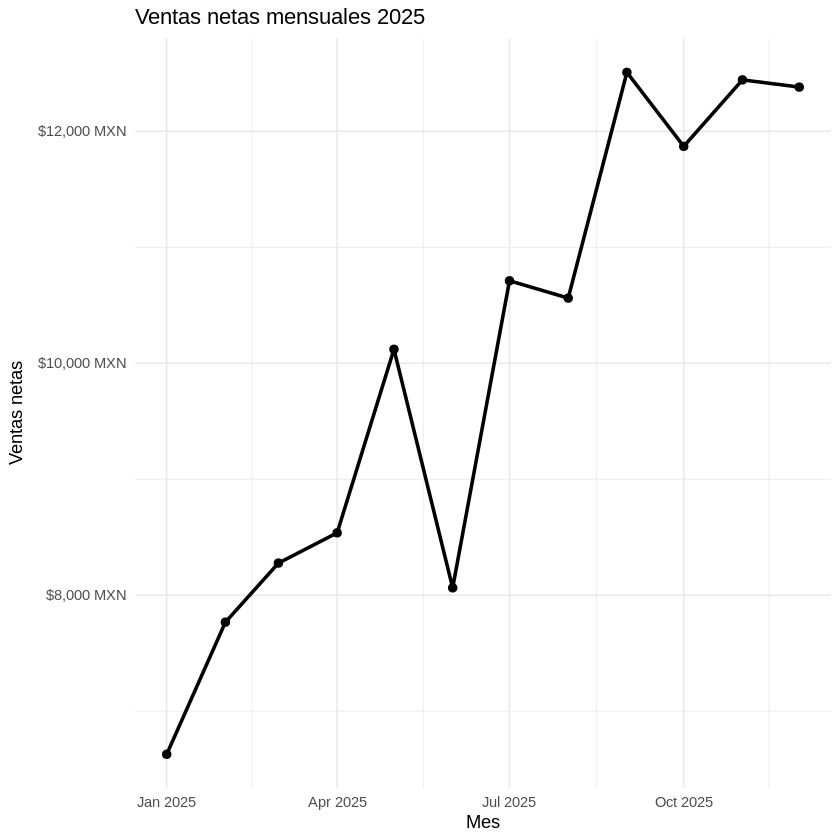

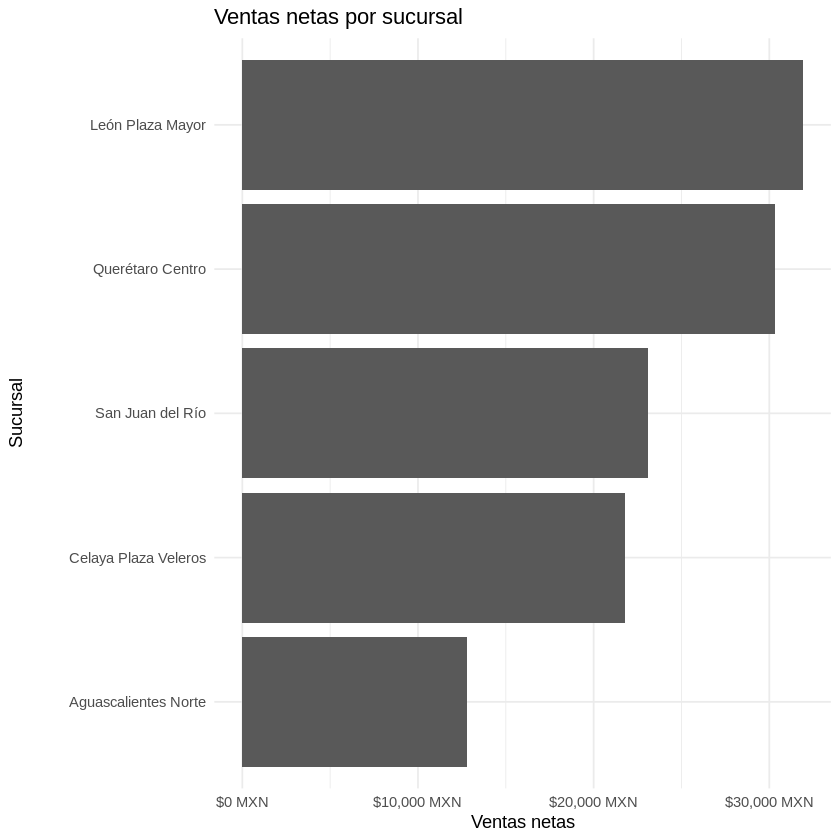

`geom_smooth()` using formula = 'y ~ x'


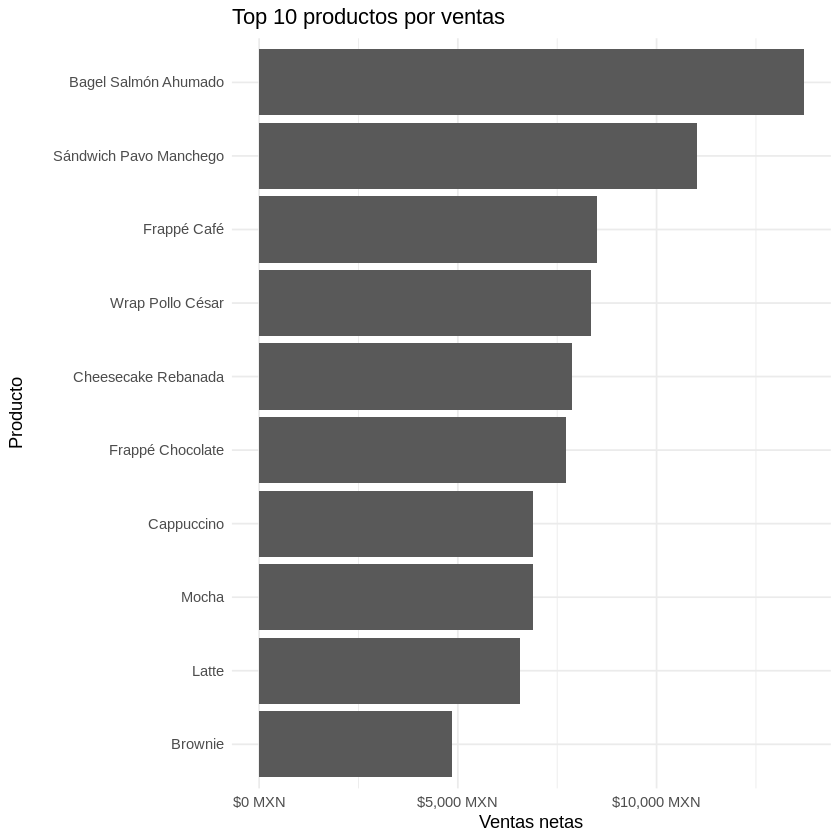

`geom_smooth()` using formula = 'y ~ x'


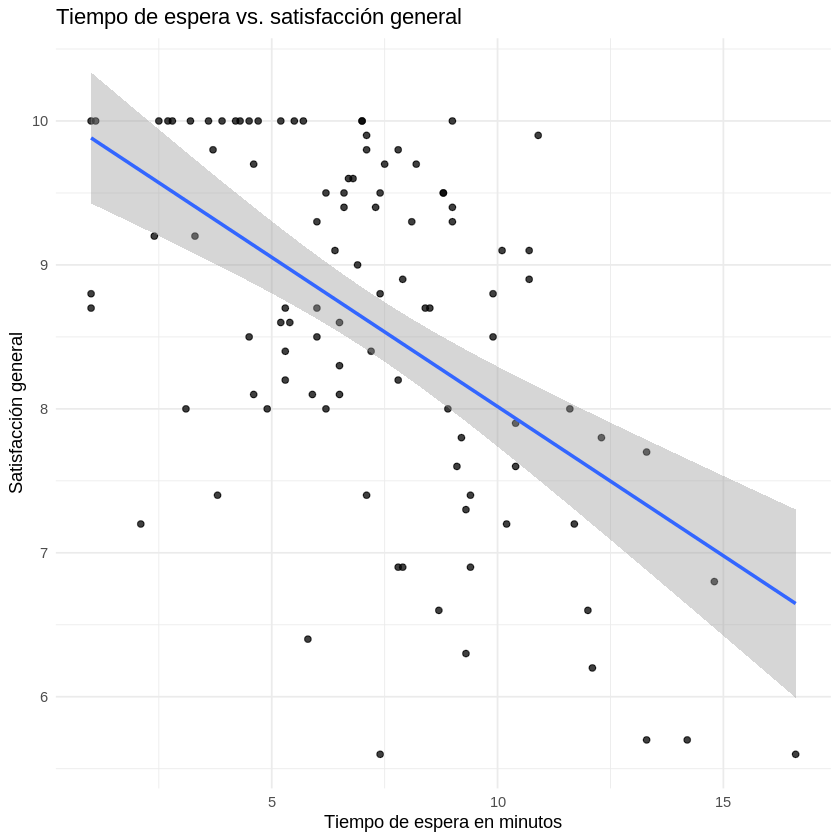

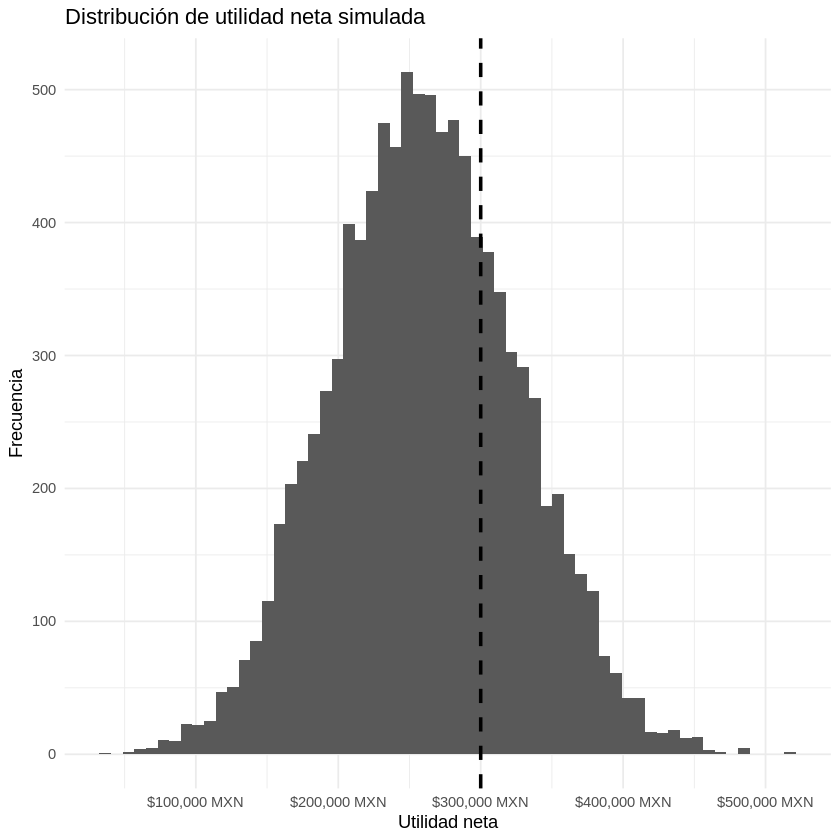

In [20]:
# Gráfica 1: Ventas netas mensuales

p1 <- ggplot(ventas_mensuales, aes(x = periodo, y = ventas_netas)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  scale_y_continuous(labels = label_dollar(prefix = "$", suffix = " MXN")) +
  labs(
    title = "Ventas netas mensuales 2025",
    x = "Mes",
    y = "Ventas netas"
  ) +
  theme_minimal()

print(p1)

ggsave(
  "/content/resultados/graficas/ventas_mensuales.png",
  p1,
  width = 9,
  height = 5,
  dpi = 300
)

# Gráfica 2: Ventas netas por sucursal

p2 <- ggplot(ventas_sucursal, aes(x = reorder(sucursal, ventas_netas), y = ventas_netas)) +
  geom_col() +
  coord_flip() +
  scale_y_continuous(labels = label_dollar(prefix = "$", suffix = " MXN")) +
  labs(
    title = "Ventas netas por sucursal",
    x = "Sucursal",
    y = "Ventas netas"
  ) +
  theme_minimal()

print(p2)

ggsave(
  "/content/resultados/graficas/ventas_sucursal.png",
  p2,
  width = 9,
  height = 5,
  dpi = 300
)

# Gráfica 3: Top 10 productos por ventas

p3 <- pareto_productos |>
  slice_head(n = 10) |>
  ggplot(aes(x = reorder(producto, ventas_netas), y = ventas_netas)) +
  geom_col() +
  coord_flip() +
  scale_y_continuous(labels = label_dollar(prefix = "$", suffix = " MXN")) +
  labs(
    title = "Top 10 productos por ventas",
    x = "Producto",
    y = "Ventas netas"
  ) +
  theme_minimal()

print(p3)

ggsave(
  "/content/resultados/graficas/top_productos.png",
  p3,
  width = 9,
  height = 5,
  dpi = 300
)

# Gráfica 4: Tiempo de espera vs satisfacción general

p4 <- ggplot(encuesta_modelo, aes(x = tiempo_espera_min, y = satisfaccion_general)) +
  geom_point(alpha = 0.75) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "Tiempo de espera vs. satisfacción general",
    x = "Tiempo de espera en minutos",
    y = "Satisfacción general"
  ) +
  theme_minimal()

print(p4)

ggsave(
  "/content/resultados/graficas/espera_satisfaccion.png",
  p4,
  width = 8,
  height = 5,
  dpi = 300
)

# Gráfica 5: Simulación Monte Carlo

p5 <- ggplot(simulacion_mc, aes(x = utilidad_neta)) +
  geom_histogram(bins = 60) +
  geom_vline(xintercept = 300000, linetype = "dashed", linewidth = 1) +
  scale_x_continuous(labels = label_dollar(prefix = "$", suffix = " MXN")) +
  labs(
    title = "Distribución de utilidad neta simulada",
    x = "Utilidad neta",
    y = "Frecuencia"
  ) +
  theme_minimal()

print(p5)

ggsave(
  "/content/resultados/graficas/montecarlo_utilidad.png",
  p5,
  width = 9,
  height = 5,
  dpi = 300
)

Insights principales

In [21]:
cat("\nINSIGHTS PRINCIPALES PARA EL REPORTE\n")
cat("1. Ventas netas totales:", dollar(sum(ventas_modelo$importe_neto, na.rm = TRUE)), "\n")
cat("2. Ticket promedio:", dollar(mean(ventas_modelo$importe_neto, na.rm = TRUE)), "\n")
cat("3. Sucursal con mayor venta:", ventas_sucursal$sucursal[1], "\n")
cat("4. Categoría con mayor venta:", ventas_categoria$categoria_producto[1], "\n")
cat("5. Satisfacción promedio:", round(resumen_encuesta$satisfaccion_promedio, 2), "\n")
cat("6. Probabilidad de utilidad mayor a $300,000 en 2026:", percent(mean(utilidad_neta > 300000)), "\n")
cat("\nPráctica terminada. Revisa la carpeta /content/resultados.\n")


INSIGHTS PRINCIPALES PARA EL REPORTE
1. Ventas netas totales: $119,872 
2. Ticket promedio: $99.89 
3. Sucursal con mayor venta: León Plaza Mayor 
4. Categoría con mayor venta: Sándwiches 
5. Satisfacción promedio: 8.6 
6. Probabilidad de utilidad mayor a $300,000 en 2026: 28% 

Práctica terminada. Revisa la carpeta /content/resultados.
